In [2]:
#load the best models from the checkpoints folder

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.utils import to_categorical 
from tensorflow.keras.models import load_model, Model
import json
import helper
import plotly.express as px

MODEL_ID = 143#35
AVERAGED = None

2024-01-18 15:24:32.576177: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
params = []
#load the json from params.json
with open('params.json') as json_file:
    params = json.load(json_file)
params = params[MODEL_ID]
print(params)
model = load_model('checkpoints/best_model_{}.h5'.format(MODEL_ID), compile=False)

{'group_size': 100, 'TEST_PROPORTION': 0.2, 'epochs': 1000, 'batch_size': 256, 'output_range': [-1, 1], 'between_layers': 4, 'first_layer_size': 256, 'layer_size_factor': 0.75, 'bottleneck_size': 2, 'num_features': 26, 'bottleneck_activation': 'linear', 'output_activation': 'linear', 'id': 143}


2024-01-18 15:24:34.878288: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-01-18 15:24:34.878472: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [4]:
#load the data

def avg(group, group_size): 
    group['GroupNumber'] = np.array(range(len(group.index))) // group_size
    res = group.groupby('GroupNumber').mean()
    return res
def load_data(group_size,output_range):
    data = pd.read_hdf("../../initialSingleCellDf-channel-20220916-MW_018-001.h5", key="df")
    #print all the columns
    ANTIGENS = ['null', 'E1', 'G4', 'V4', 'T4', 'Q4', 'A2', 'N4']
    data = data.loc[(data.index.get_level_values('CellType') == 'OT-1') & 
                       (data.index.get_level_values('Peptide').isin(ANTIGENS))
                    ]
    data = data.groupby(['Peptide', 'Time', 'Replicate', 'Concentration']).apply(avg, group_size=group_size)
    antigen = list(data.index.get_level_values('Peptide'))
    times = list(data.index.get_level_values('Time'))
    concentration = list(data.index.get_level_values('Concentration'))
    scaling_factor = 1024/(output_range[1]-output_range[0])
    X = np.array(data.values)/scaling_factor + output_range[0]
    y = np.array(list(map(lambda x: ANTIGENS.index(x), antigen)))
    y = to_categorical(y)
    return X,y,times,concentration

def get_model_embedding(model,params):
    X, y,times,concentration = load_data(params['group_size'] if AVERAGED == None else AVERAGED,params['output_range'])
    extractor = Model(inputs=model.inputs,
                        outputs=model.get_layer("Bottleneck").output)
    embedding = np.array(extractor(X))
    output = np.argmax(y,axis=1)
    ANTIGENS = ["null", "E1", "G4", "V4", "T4", "Q4", "A2", "N4"]
    output = np.array(ANTIGENS)[output]
    num_embedding_dimensions = embedding.shape[1]
    df = pd.DataFrame(embedding, columns=['Dimension '+str(i+1) for i in range(num_embedding_dimensions)])
    df["Antigen"] = output
    df["Time"] = times
    df["Concentration"] = concentration
    return df

In [5]:
embedding = get_model_embedding(model,params)

In [6]:

def get_3d_plot(df,title,color='Antigen'):
    fig = px.scatter_3d(
        df,
        x='Dimension 1',
        y='Dimension 2',
        z='Dimension 3',
        color=color,
        title=title,
        # range_x=[-1,1],
        # range_y=[-1,1],
        # range_z=[-1,1]
    )

    fig.update_traces(marker=dict(size=4))
    fig.update_layout(legend_title="Antigen")
    fig.show()

def get_2d_plot(df,title,color='Antigen'):
    #get the min and max of the two dimensions
    x_range= [min(df['Dimension 1']),max(df['Dimension 1'])]
    y_range= [min(df['Dimension 2']),max(df['Dimension 2'])]
    fig = px.scatter(
        df,
        x='Dimension 1',
        y='Dimension 2',
        color=color,
        title=title,
        range_x=x_range,
        range_y=y_range,
        opacity=0.1
    )

    fig.update_traces(marker=dict(size=4))
    fig.update_layout(legend_title="Antigen")
    fig.show()
def get_2d_line_plot(df,title,color='Antigen'):
    #get the min and max of the two dimensions
    x_range= [min(df['Dimension 1']),max(df['Dimension 1'])]
    y_range= [min(df['Dimension 2']),max(df['Dimension 2'])]
    fig = px.line(
        df,
        x='Dimension 1',
        y='Dimension 2',
        color=color,
        title=title,
        range_x=x_range,
        range_y=y_range,
    )

    fig.update_traces(marker=dict(size=4))
    fig.update_layout(legend_title="Antigen")
    fig.show()

In [7]:

ANTIGENS = ["null", "E1", "G4", "V4", "T4", "Q4", "A2", "N4"]

# for i in range(len(ANTIGENS)):
#    #plot the data for each antigen
#     antigen = ANTIGENS[i]
#     antigen_df = embedding[embedding["Antigen"] == antigen]
#     get_3d_plot(antigen_df,"Autoencoder 3D Embedding Averaged Data (Validation Set) for " + antigen,color='Time')

get_2d_plot(embedding,"Autoencoder 2D Embedding for All Antigens",color="Antigen")
get_2d_plot(embedding,"Autoencoder 2D Embedding for All Antigens",color="Time")


In [8]:
antigen = "A2"
emb = embedding[embedding['Antigen'] == antigen]
get_2d_plot(emb,"Autoencoder 2D Embedding for "+antigen,color="Concentration")
get_2d_plot(emb,"Autoencoder 2D Embedding for "+antigen,color="Time")

In [39]:
grouped = embedding.groupby(["Time","Antigen","Concentration"]).mean().reset_index()
#get starting point by averaging Dimension 1 and Dimension 2 for all the points where time is 
starting_points = grouped[grouped["Time"] == 4]
#add a column for the starting point for each antigen and concentration set
grouped_displacements= []
for i in range(len(grouped)):
    start = starting_points[(starting_points["Antigen"] == grouped.iloc[i]["Antigen"]) & (starting_points['Concentration'] == grouped.iloc[i]['Concentration'])]
    grouped_displacement = np.sqrt((grouped.iloc[i]['Dimension 1'] - start["Dimension 1"].values[0])**2 + (grouped.iloc[i]['Dimension 2'] - start["Dimension 2"].values[0])**2)
    grouped_displacements.append(grouped_displacement)
grouped["Displacement"] = grouped_displacements
grouped["Antigen-Concentration"] = grouped["Antigen"] + " " + grouped["Concentration"].astype(str)

In [38]:
#add extra column that is a combination of antigen and concentration
get_2d_line_plot(grouped,"Autoencoder 2D Embedding Averaged Data (Validation Set) for All Antigens",color="Antigen-Concentration")


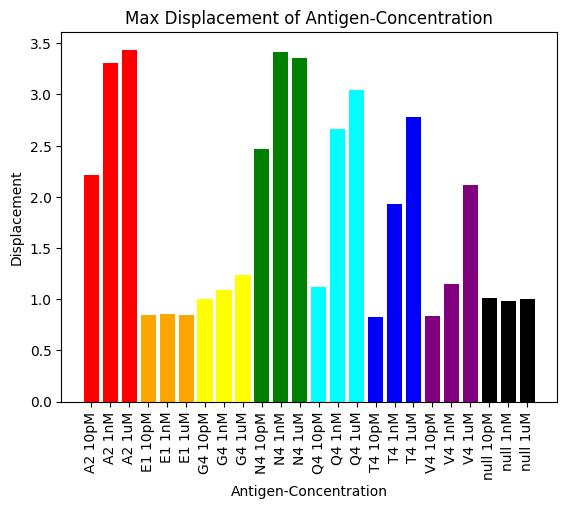

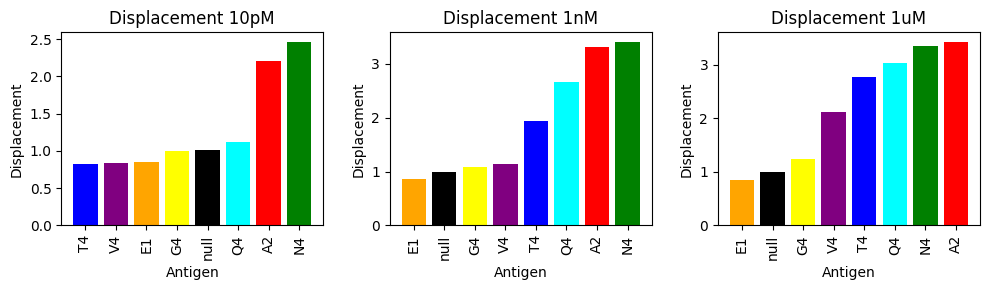

In [64]:
#for each "Antigen-Concentration", plot displacement over time all on the same matplot
x =[]
y=[]
nulls = []
for antigen_concentration in grouped["Antigen-Concentration"].unique():
    antigen_concentration_df = grouped[grouped["Antigen-Concentration"] == antigen_concentration]
    #max displacement
    max_displacement = max(antigen_concentration_df["Displacement"])
    if "null" in antigen_concentration:
        nulls.append(max_displacement)
    #bar graph of max_displacement labeled with antigen_concentration
    x.append(antigen_concentration)
    y.append(max_displacement)
#average the nulls
nulls = np.array(nulls)
nulls = np.mean(nulls)
#normalize the y values
y = np.array(y)
y = y/nulls
#matplotlib bar graph

antigen_colors = {
    "A2":"#FF0000",
    "E1":"#FFA500",
    "G4":"#FFFF00",
    "N4":"#008000",
    "Q4":"#00FFFF",
    "T4":"#0000FF",
    "V4":"#800080",
    "null":"#000000"
}
plt.bar(x,y,color=[antigen_colors[antigen.split(" ")[0]] for antigen in x])
plt.xticks(rotation=90)
plt.ylabel("Displacement")
plt.xlabel("Antigen-Concentration")
plt.title("Max Displacement of Antigen-Concentration")
plt.show()

#splt x and y into groups based on concentration
x_by_concentration = {}
y_by_concentration = {}

for i in range(len(x)):
    concentration = x[i].split(" ")[1]
    if concentration not in x_by_concentration:
        x_by_concentration[concentration] = []
        y_by_concentration[concentration] = []
    x_by_concentration[concentration].append(x[i])
    y_by_concentration[concentration].append(y[i])

#plot the concentration groups
plt.figure(figsize=(10,3))
count = 1
for concentration in x_by_concentration:
    #sort the x and y values by y
    plt_x,plt_y = zip(*sorted(zip(x_by_concentration[concentration],y_by_concentration[concentration]),key=lambda x: x[1]))
    #remove the concentration from the x values
    plt_x = [antigen.split(" ")[0] for antigen in plt_x]
    plt.subplot(1,3,count)
    plt.bar(plt_x,plt_y,color=[antigen_colors[antigen.split(" ")[0]] for antigen in plt_x])
    plt.xticks(rotation=90)
    plt.ylabel("Displacement")
    plt.xlabel("Antigen")
    plt.title("Displacement " + concentration)
    count += 1
plt.tight_layout()
plt.show()